# Crop Leaf Disease Detection — AWS SageMaker Studio Training
**Dataset:** PlantVillage for Object Detection (YOLO format)  
**Methodology:** 13 Features (RGB+Grayscale) + HOG + Gaussian Blur + PCA → Random Forest (500 trees, max_depth=25)  
**Output:** `confusion_matrix.png`, `classification_report.txt`, `leaf_disease_pipeline.pkl`

### Instructions
1. Upload your `kaggle.json` to the SageMaker file browser (same directory as this notebook).
2. Run all cells in order.
3. Download the output files from the SageMaker file browser when done.

In [1]:
!pip install -q kaggle scikit-learn opencv-python-headless matplotlib joblib pyyaml scikit-image "numpy<2"

In [2]:
# ---- Set up Kaggle API token ----
import os

kaggle_src = "kaggle.json"
kaggle_dst = os.path.expanduser("~/.kaggle/kaggle.json")

if not os.path.exists(kaggle_src):
    raise FileNotFoundError(
        "kaggle.json not found! Upload it to the SageMaker file browser "
        "(same directory as this notebook) before running this cell.\n"
        "Get it from: kaggle.com -> My Account -> API -> Create New Token"
    )

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
import shutil
shutil.copy(kaggle_src, kaggle_dst)
os.chmod(kaggle_dst, 0o600)
print("Kaggle API token configured.")

Kaggle API token configured.


In [3]:
# ---- Download the YOLO-format PlantVillage dataset ----
os.system("kaggle datasets download sebastianpalaciob/plantvillage-for-object-detection-yolo -p ./data --unzip")
print("\nDataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo
License(s): CC-BY-NC-SA-4.0


100%|██████████| 829M/829M [00:53<00:00, 16.3MB/s] 




Dataset downloaded!


In [4]:
# ---- Explore dataset structure ----
print("Dataset structure:")
for root, dirs, fls in os.walk("./data"):
    depth = root.replace("./data", "").count(os.sep)
    if depth < 3:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/ ({len(fls)} files)")
    if depth >= 3:
        break

Dataset structure:
data/ (0 files)
  PlantVillage_for_object_detection/ (2 files)
    Dataset/ (1 files)


In [5]:
# ---- Find the data.yaml to get class names ----
import glob, yaml

yaml_files = glob.glob("./data/**/*.yaml", recursive=True)
print(f"Found YAML configs: {yaml_files}")

class_names = []
if yaml_files:
    with open(yaml_files[0], "r") as f:
        data_config = yaml.safe_load(f)
    class_names = data_config.get("names", [])
    print(f"Classes from YAML: {class_names}")
    print(f"Number of classes: {data_config.get('nc', len(class_names))}")

# If no YAML found, use default PlantVillage classes
if not class_names:
    class_names = [
        "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
        "Blueberry___healthy", "Cherry_(including_sour)___Powdery_mildew", "Cherry_(including_sour)___healthy",
        "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_", 
        "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___healthy", "Grape___Black_rot",
        "Grape___Esca_(Black_Measles)", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Grape___healthy",
        "Orange___Haunglongbing_(Citrus_greening)", "Peach___Bacterial_spot", "Peach___healthy",
        "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
        "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
        "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
        "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight",
        "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites Two-spotted_spider_mite",
        "Tomato___Target_Spot", "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus",
        "Tomato___healthy"
    ]
    print(f"Using default classes: {class_names}")

Found YAML configs: ['./data/PlantVillage_for_object_detection/Dataset/classes.yaml']
Classes from YAML: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spo

In [6]:
# ---- Find image and label folders ----
import cv2
import numpy as np

def find_folders(base, name):
    """Find all folders matching a name pattern."""
    results = []
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            if d == name:
                results.append(os.path.join(root, d))
    return results

# Find image folders
image_folders = find_folders("./data", "images")
if not image_folders:
    image_folders = glob.glob("./data/**/train", recursive=True)

print(f"Image folders found: {image_folders}")

# Find label folders
label_folders = find_folders("./data", "labels")
print(f"Label folders found: {label_folders}")

Image folders found: ['./data/PlantVillage_for_object_detection/Dataset/images']
Label folders found: ['./data/PlantVillage_for_object_detection/Dataset/labels']


In [7]:
# ---- Feature Extraction (RGB + Grayscale + Blur + HOG) ----
from skimage.feature import hog
from sklearn.decomposition import PCA

def extract_features(image):
    """Extract RGB, Grayscale Statistics, and HOG Textures with Gaussian Blur."""
    # 1. Blur the image to remove background noise (dirt, sky)
    img_blurred = cv2.GaussianBlur(image, (5, 5), 0)
    
    # Resize to keep computations fast
    img_resized = cv2.resize(img_blurred, (128, 128))
    
    # 2. RGB Color Features
    b_mean, g_mean, r_mean = np.mean(img_resized, axis=(0, 1))
    b_std, g_std, r_std = np.std(img_resized, axis=(0, 1))
    
    # 3. Grayscale Statistical Features
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hist = np.histogram(gray, bins=256)[0]
    hist = hist / np.sum(hist)
    
    gray_features = [
        r_mean, g_mean, b_mean,           
        r_std, g_std, b_std,              
        np.mean(gray),                    
        np.std(gray),                     
        np.min(gray),                     
        np.max(gray),                     
        np.median(gray),                  
        np.var(gray),                     
        -np.sum(hist * np.log2(hist + 1e-7)) 
    ]
    
    # 4. HOG Textures (Shape of the disease spots)
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    
    # Combine all features into one giant array
    return np.hstack([gray_features, hog_features])


def get_class_from_label(label_path, class_names):
    """Read a YOLO label file and return the most common class name."""
    if not os.path.exists(label_path):
        return None
    with open(label_path, "r") as f:
        lines = f.readlines()
    if not lines:
        return None
    
    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                class_ids.append(int(parts[0]))
            except ValueError:
                continue

    if not class_ids:
        return None
        
    most_common = max(set(class_ids), key=class_ids.count)
    if most_common < len(class_names):
        return class_names[most_common]
    return f"class_{most_common}"

In [8]:
# ---- Load all images and extract features ----
features = []
labels = []
class_counts = {}

# Process each image folder (train + val)
for img_folder in image_folders:
    # Find corresponding label folder
    label_folder = img_folder.replace("images", "labels")
    if not os.path.exists(label_folder):
        print(f"  No label folder for {img_folder}, skipping")
        continue

    print(f"\nProcessing: {img_folder}")
    for img_file in sorted(os.listdir(img_folder)):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(img_folder, img_file)
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(label_folder, label_file)

        # Get class from YOLO label
        cls = get_class_from_label(label_path, class_names)
        if cls is None:
            continue

        # Read image and extract features
        image = cv2.imread(img_path)
        if image is None:
            continue

        feat = extract_features(image)
        features.append(feat)
        labels.append(cls)
        class_counts[cls] = class_counts.get(cls, 0) + 1

print(f"\n{'='*50}")
print(f"  DATASET SUMMARY")
print(f"{'='*50}")
print(f"Total samples: {len(features)}")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count} images")


Processing: ./data/PlantVillage_for_object_detection/Dataset/images

  DATASET SUMMARY
Total samples: 54293
  Apple___Apple_scab: 630 images
  Apple___Black_rot: 621 images
  Apple___Cedar_apple_rust: 275 images
  Apple___healthy: 1645 images
  Blueberry___healthy: 1502 images
  Cherry___Powdery_mildew: 1052 images
  Cherry___healthy: 853 images
  Corn___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn___Common_rust: 1192 images
  Corn___Northern_Leaf_Blight: 983 images
  Corn___healthy: 1157 images
  Grape___Black_rot: 1180 images
  Grape___Esca_(Black_Measles): 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 5507 images
  Peach___Bacterial_spot: 2297 images
  Peach___healthy: 360 images
  Pepper,_bell___Bacterial_spot: 997 images
  Pepper,_bell___healthy: 1477 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Raspberry__

In [9]:
# ---- Train/Test Split & Dimensionality Reduction ----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = np.array(features), np.array(labels)

print("Compressing Data (PCA) to keep Model Size Small...")
# Standardize the Data (Required for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA Compression: Shrink thousands of HOG features down to retaining 95% of information
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"Compressed from {X.shape[1]} features down to {X_pca.shape[1]} features!")

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Compressing Data (PCA) to keep Model Size Small...
Compressed from 8113 features down to 2074 features!

Train: 43434, Test: 10859


In [10]:
# ---- Train Random Forest ----
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (500 trees, max_depth=25, balanced)...")
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Training Random Forest (500 trees, max_depth=25, balanced)...


In [11]:
# ---- Results ----
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"  ACCURACY: {accuracy:.2%}")
print(f"{'='*50}")

report = classification_report(y_test, y_pred)
print("\nClassification Report:\n")
print(report)

# Save report
with open("classification_report.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.2%}\n\n")
    f.write(f"Dataset: PlantVillage for Object Detection (YOLO format)\n")
    f.write(f"Total samples: {len(X)}\n")
    f.write(f"Train: {len(X_train)}, Test: {len(X_test)}\n\n")
    f.write(report)
print("Saved classification_report.txt")


  ACCURACY: 53.55%

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.00      0.00      0.00       126
                            Apple___Black_rot       0.70      0.52      0.60       124
                     Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                              Apple___healthy       0.31      0.21      0.25       329
                          Blueberry___healthy       0.55      0.21      0.30       300
                      Cherry___Powdery_mildew       0.64      0.43      0.51       210
                             Cherry___healthy       0.82      0.25      0.38       171
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.08      0.14       103
                           Corn___Common_rust       0.88      0.94      0.91       238
                  Corn___Northern_Leaf_Blight       0.51      0.76      0.61       1

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


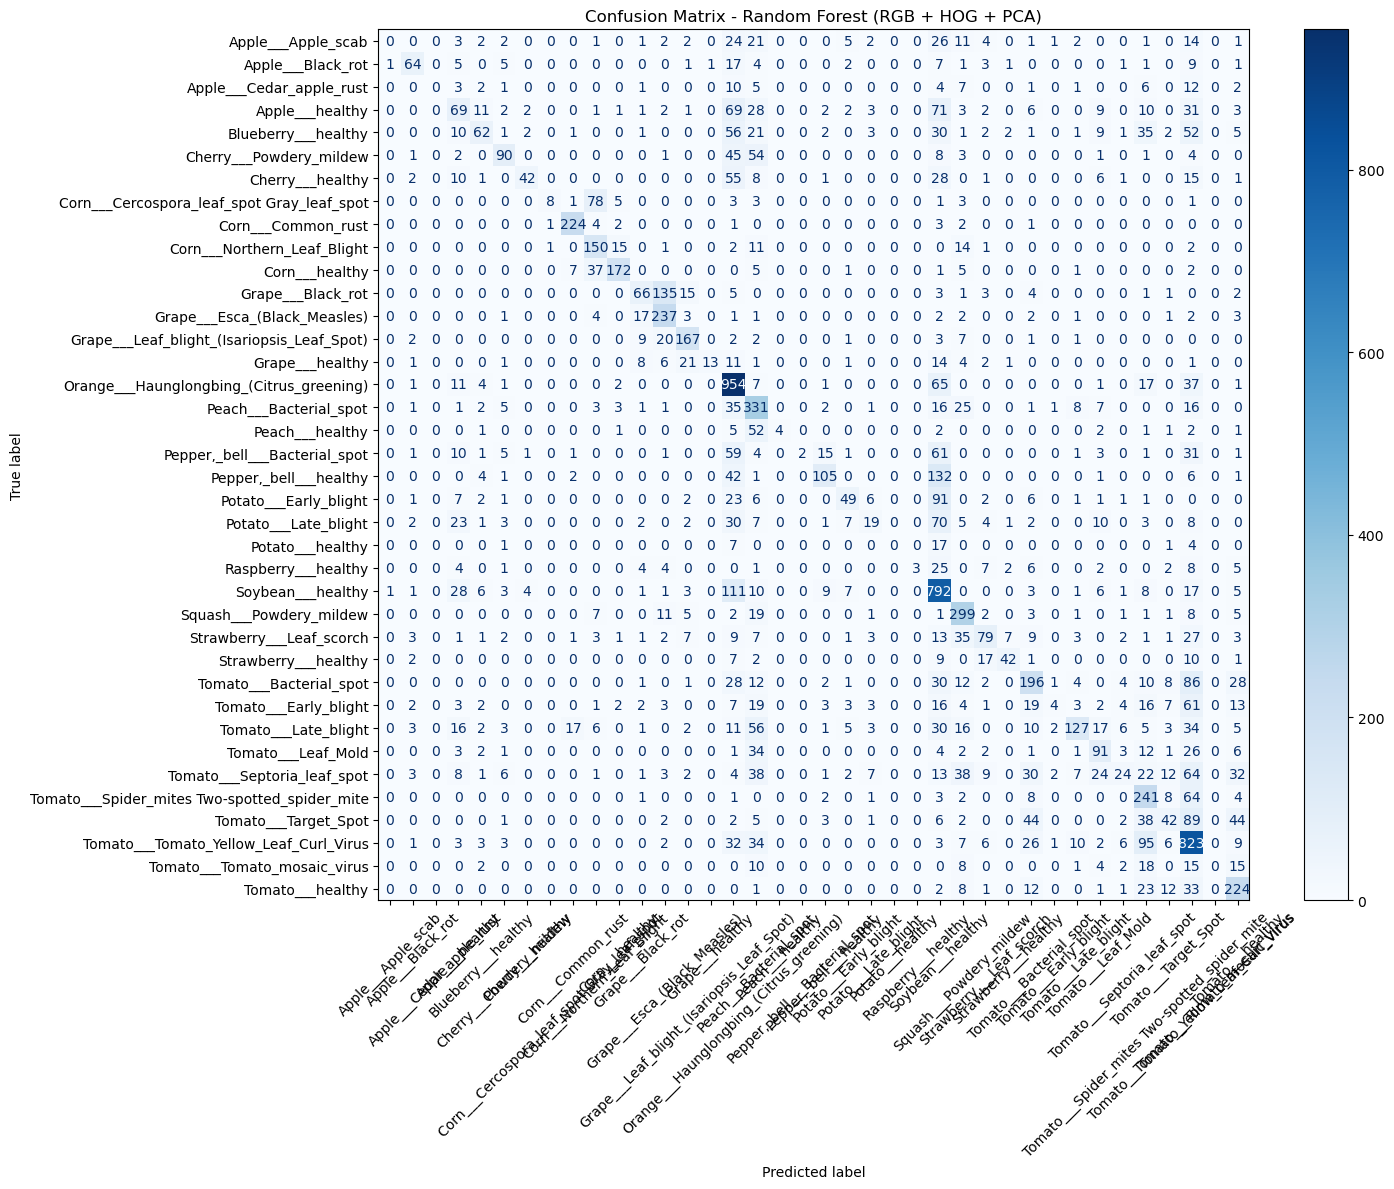

Saved confusion_matrix.png


In [12]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(15, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest (RGB + HOG + PCA)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")

In [13]:
# ---- Save pipeline (scaler + PCA + model) ----
import joblib

# Fix the 5GB Joblib bloat bug: Compress by default and clear n_jobs
model.n_jobs = 1

pipeline = {
    "scaler": scaler,
    "pca": pca,
    "model": model,
    "classes": model.classes_
}

joblib.dump(pipeline, "leaf_disease_pipeline.pkl", compress=3)
print("Saved leaf_disease_pipeline.pkl")

Saved leaf_disease_pipeline.pkl


In [14]:
print("DONE! Output files in the current directory:")
print("  confusion_matrix.png")
print("  classification_report.txt")
print("  leaf_disease_pipeline.pkl")
print("\nDownload them from the SageMaker file browser (left panel).")

DONE! Output files in the current directory:
  confusion_matrix.png
  classification_report.txt
  leaf_disease_pipeline.pkl

Download them from the SageMaker file browser (left panel).
